# 北極海氷：長期傾向と季節変動の分離
run_id: `v020-exp-22` / AI Data Scientist Skill / 全分析・APIコードはJupyter MCP実行。

## 分析計画
1. Kaggle SDKで公開候補を検索し、提供主体と内容を確認して選定。日付・単位・半球・観測間隔・欠測を検査する。
2. 月平均を作り、全12か月が採用できる年の年平均で長期傾向を示す。月固定効果+線形傾向で平均的季節成分と残差を分離する。
3. 年平均傾向・季節曲線・季節調整後の時系列を図示し、根拠付きInsightを記録する。
4. 初回結果を読み直し、重み/期間/頑健推定、季節形の変化、自己相関の影響を最大3回追加検証する。
5. カーネル再起動後、全コードセルを上からJupyter MCPで再実行。原本SHA・初回数値との一致・図/Notebook監査・ライフサイクルを確認する。

## データ選定と来歴
Kaggle参照検索：https://www.kaggle.com/datasets?search=arctic+sea+ice+extent

選定：`nsidcorg/daily-sea-ice-extent-data` の `seaice.csv`。他の転載候補よりNSIDC掲載を優先。取得成功のためseaborn公開CSVフォールバックは未使用。取得日時・SHA-256は取得セルとdata/provenance.jsonに記録。元CSVを変更せず保存し、再実行ではSHAを検証した固定原本を再利用する。認証トークンは変数表示/ログ/Notebookに出さない。

Kaggleの説明文は1978–2015年だが、実CSVは1978-10-26〜2019-05-31年。北半球のみ13177観測、南半球を混合しない。単位はKaggle定義の10^6 km²（百万km²）。最終結論の適用期間は最新年ではなく1979–2018年である。


In [1]:
# 実行設定・ライフサイクル (run_id: v020-exp-22)
from pathlib import Path
from datetime import datetime, timezone
from contextlib import contextmanager, redirect_stdout, redirect_stderr
import sys, os, io, json, hashlib, warnings, re, zipfile
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display
from ai_data_scientist import project_manager, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions
from ai_data_scientist import data_quality, sensitivity, visualization, insight_engine, notebook_audit
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-22-seaice')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
RUN_ID = 'v020-exp-22'
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(name, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行取消が要求されました')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    phase_log.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    start(RUN_ID)
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed'})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
print('言語:', language_router.detect_language('北極海氷の長期傾向と季節変動を分析する'))
print('実行登録:', lifecycle.get_run_status(RUN_ID))

言語: ja
実行登録: RunStatus(run_id='v020-exp-22', state='running', active_cell_executions=0, pending_notebook_writes=0, locks_held=0, notebook_path='/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-22-seaice/notebooks/kaggle-v020-kaggle-exp-22-seaice.ipynb', reason=None)


In [2]:
# Kaggle SDKによる認証・検索・ファイル一覧。秘密情報は出力しない。
kaggle_log = []
kaggle_candidates = []
kaggle_files = {}
kaggle_failure = None
with phase('Kaggle認証・検索'):
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        kaggle_log.append({'operation': 'KaggleApi().authenticate()', 'status': 'ok'})
        for query in ['arctic sea ice extent', 'sea ice extent']:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query, page=1)
            items = [{'ref': str(d.ref), 'title': str(d.title)} for d in found]
            kaggle_log.append({'operation': 'dataset_list', 'search': query, 'count': len(items)})
            for item in items:
                if item['ref'] not in [d['ref'] for d in kaggle_candidates]:
                    kaggle_candidates.append(item)
        for item in kaggle_candidates[:8]:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(item['ref'])
            files = getattr(listing, 'files', None) or getattr(listing, 'dataset_files', [])
            kaggle_files[item['ref']] = [str(f.name) for f in files]
        if not kaggle_candidates:
            kaggle_failure = {'operation': 'dataset_list', 'type': 'NoMatchingDataset', 'reason': '検索結果なし'}
    except (Exception, SystemExit) as exc:
        # SDK例外メッセージは認証情報/ヘッダを含み得るため、型と安全な固定説明だけを保存。
        kaggle_failure = {'operation': kaggle_log[-1]['operation'] if kaggle_log else 'authenticate/import',
                          'type': type(exc).__name__, 'reason': '認証・検索・一覧のいずれかが失敗。秘密保護のため生の例外を保存しない。'}
        kaggle_log.append({'status': 'failed', **kaggle_failure})
print(json.dumps({'APIログ': kaggle_log, '候補': kaggle_candidates[:15], 'ファイル一覧': kaggle_files, '失敗': kaggle_failure}, ensure_ascii=False, indent=2))

{
  "APIログ": [
    {
      "operation": "KaggleApi().authenticate()",
      "status": "ok"
    },
    {
      "operation": "dataset_list",
      "search": "arctic sea ice extent",
      "count": 10
    },
    {
      "operation": "dataset_list",
      "search": "sea ice extent",
      "count": 18
    }
  ],
  "候補": [
    {
      "ref": "jarredpriester/arctic-sea-ice-extent",
      "title": "Arctic Sea Ice Extent"
    },
    {
      "ref": "willianoliveiragibin/arctic-sea-ice-extent",
      "title": "Arctic sea ice extent"
    },
    {
      "ref": "mpwolke/cusersmarildownloadsbiodiversitycsv",
      "title": "Biodiversity - Golden Plains Roadside "
    },
    {
      "ref": "jeanpierretanguay/monthly-sea-ice-index",
      "title": "Monthly Sea Ice Index"
    },
    {
      "ref": "sergionefedov/climate-and-weather-anomalies-196-cities-75-years",
      "title": "Climate & Weather Anomalies 196 cities · 75 years"
    },
    {
      "ref": "blakefeiza/mm-2018w15-arctic-sea-ice-extent",
  

In [3]:
# 提供主体を優先してNSIDC掲載版を選定。他候補は更新時点・定義の確認用。
with phase('Kaggle選定・メタデータ'):
    SELECTED_SLUG = 'nsidcorg/daily-sea-ice-extent-data'
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        listing = api.dataset_list_files(SELECTED_SLUG)
        api.dataset_metadata(SELECTED_SLUG, path=str(data_dir))
    chosen_files = [str(f.name) for f in (getattr(listing, 'files', None) or getattr(listing, 'dataset_files', []))]
    metadata_path = data_dir / 'dataset-metadata.json'
    kaggle_metadata = json.loads(metadata_path.read_text())
    kaggle_log.append({'operation': 'dataset_list_files', 'slug': SELECTED_SLUG, 'files': chosen_files})
print('owner/dataset:', SELECTED_SLUG)
print('取得可能ファイル:', chosen_files)
print('説明:', kaggle_metadata.get('description', '')[:14000])
print('ライセンス:', kaggle_metadata.get('licenses'))

owner/dataset: nsidcorg/daily-sea-ice-extent-data
取得可能ファイル: ['seaice.csv']
説明: 
ライセンス: None


In [4]:
# ファイル取得と固定したバイト列の来歴記録。再実行はSHA照合済みローカル原本を使用。
with phase('Kaggle CSV取得と読込'):
    provenance_path = data_dir / 'provenance.json'
    raw_path = data_dir / 'seaice.csv'
    if provenance_path.exists() and raw_path.exists():
        provenance = json.loads(provenance_path.read_text())
        assert hashlib.sha256(raw_path.read_bytes()).hexdigest() == provenance['sha256'], '原本SHA不一致'
        acquisition_mode = '固定原本を再利用・SHA-256検証済み'
    else:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            api.dataset_download_file(SELECTED_SLUG, 'seaice.csv', path=str(data_dir), force=True, quiet=True)
        archive = data_dir / 'seaice.csv.zip'
        if not raw_path.exists() and archive.exists():
            with zipfile.ZipFile(archive) as z:
                member = next(n for n in z.namelist() if Path(n).name == 'seaice.csv')
                raw_path.write_bytes(z.read(member))
        assert raw_path.exists(), 'CSVが取得されていない'
        provenance = {'owner_dataset_slug': SELECTED_SLUG, 'filename': 'seaice.csv',
                      'source_url': 'https://www.kaggle.com/datasets/' + SELECTED_SLUG,
                      'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                      'sha256': hashlib.sha256(raw_path.read_bytes()).hexdigest(),
                      'fallback_used': False, 'kaggle_failure': None}
        provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2))
        acquisition_mode = 'Kaggle SDK dataset_download_file 取得成功'
    loaded = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(raw_path)), row_limit=100000)
    raw = loaded.dataframe
print('取得方法:', acquisition_mode)
print(json.dumps(provenance, ensure_ascii=False, indent=2))
print('CSV冒頭:', raw_path.read_text()[:500])
print('行列:', raw.shape, '打切り:', loaded.truncated)
display(raw.head(8)); display(raw.tail(8))
print('メタデータ:', json.dumps(kaggle_metadata, ensure_ascii=False)[:10000])

取得方法: 固定原本を再利用・SHA-256検証済み
{
  "owner_dataset_slug": "nsidcorg/daily-sea-ice-extent-data",
  "filename": "seaice.csv",
  "source_url": "https://www.kaggle.com/datasets/nsidcorg/daily-sea-ice-extent-data",
  "retrieved_at_utc": "2026-10-01T19:24:57.592271+00:00",
  "sha256": "90a514812839a0c3edfd7540dbc17361b8f0b8e4368fb8aee5944468b6d398d1",
  "fallback_used": false,
  "kaggle_failure": null
}
CSV冒頭: Year, Month, Day,     Extent,    Missing, Source Data,hemisphere
1978,10,26,10.231,0, ['ftp://sidads.colorado.edu/pub/DATASETS/nsidc0051_gsfc_nasateam_seaice/final-gsfc/north/daily/1978/nt_19781026_n07_v1.1_n.bin'],north
1978,10,28,10.42,0, ['ftp://sidads.colorado.edu/pub/DATASETS/nsidc0051_gsfc_nasateam_seaice/final-gsfc/north/daily/1978/nt_19781028_n07_v1.1_n.bin'],north
1978,10,30,10.557,0, ['ftp://sidads.colorado.edu/pub/DATASETS/nsidc0051_gsfc_nasateam_seaice/final-gsfc/north/daily/1978/nt_
行列: (26354, 7) 打切り: False
メタデータ: {"info": {"datasetId": 499, "datasetSlug": "daily-sea-ice-exten

,Year,Month,Day,Extent,Missing,Source Data,hemisphere
0,1978,10,26,10.231,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
1,1978,10,28,10.420,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
2,1978,10,30,10.557,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
3,1978,11,1,10.670,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
4,1978,11,3,10.777,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
5,1978,11,5,10.968,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
6,1978,11,7,11.080,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
7,1978,11,9,11.189,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north


,Year,Month,Day,Extent,Missing,Source Data,hemisphere
26346,2019,5,24,9.806,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26347,2019,5,25,9.918,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26348,2019,5,26,10.014,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26349,2019,5,27,10.085,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26350,2019,5,28,10.078,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26351,2019,5,29,10.219,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26352,2019,5,30,10.363,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south
26353,2019,5,31,10.436,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsidc...,south


In [5]:
# 時間軸・単位・意味的異常検査とEDA
from dataclasses import asdict
import requests
with phase('データ定義と意味的品質検査'):
    df = raw.rename(columns=lambda c: c.strip()).copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']].rename(columns={'Year':'year', 'Month':'month', 'Day':'day'}), errors='raise')
    df['hemisphere'] = df['hemisphere'].str.strip()
    assert {'Extent','Missing','Year','Month','Day','date','hemisphere'}.issubset(df.columns)
    anomalies = data_quality.detect_anomalies(df, schema={
        'Year': {'min':1978,'max':datetime.now(timezone.utc).year,'not_null':True},
        'Month': {'min':1,'max':12,'not_null':True}, 'Day': {'min':1,'max':31,'not_null':True},
        'Extent': {'min':0,'max':25,'not_null':True}, 'Missing': {'min':0,'max':25,'not_null':True},
        'hemisphere': {'allowed':['north','south'],'not_null':True}, 'date': {'not_null':True}})
    print('意味的異常:', [asdict(a) for a in anomalies])
    print('半球別行数・期間:'); display(df.groupby('hemisphere').agg(rows=('date','size'), start=('date','min'), end=('date','max')))
    clean_report = cleaning.clean_dataset(df, operation='drop_duplicates')
    df = clean_report.dataframe
    print('完全重複除去:', clean_report.rows_before, '→', clean_report.rows_after, '削除:', clean_report.rows_removed)
    assert not df.duplicated(['hemisphere','date']).any(), '日付キーの重複'
    north = df.loc[df.hemisphere.eq('north')].sort_values('date').copy()
    north_quality = data_quality.detect_anomalies(north, {'date': {'unique':True, 'not_null':True}})
    gaps = north.date.diff().dt.days
    print('北半球観測間隔（日）:'); display(gaps.value_counts().sort_index().to_frame('count'))
    print('長いギャップ:'); display(north.loc[gaps.gt(3), ['date','Extent']].assign(gap_days=gaps[gaps.gt(3)]))
    print('Missing>0:', int(north.Missing.gt(0).sum()), '最大Missing:', north.Missing.max())
    report_eda = eda.explore(north[['Extent','Missing','Year','Month','Day','hemisphere']], top_n=3)
    print('EDA欠測:', report_eda.missing_summary); display(pd.DataFrame(report_eda.describe))
    # 公的定義の確認用ページ。ネットワーク失敗は明示し、検証済みに昇格しない。
    definition_url = 'https://nsidc.org/learn/parts-cryosphere/sea-ice/sea-ice-science'
    definition_cache = data_dir / 'nsidc-sea-ice-science.html'
    definition_verified = False
    try:
        if not definition_cache.exists():
            response = requests.get(definition_url, timeout=40); response.raise_for_status()
            definition_cache.write_bytes(response.content)
        text = re.sub('<[^>]+>', ' ', definition_cache.read_text(errors='replace'))
        definition_verified = bool(re.search(r'15\s*(?:percent|%)', text, re.I)) and 'extent' in text.lower()
        print('NSIDC閾値定義確認:', definition_verified, definition_url)
    except requests.RequestException as exc:
        print('定義ページ取得失敗:', type(exc).__name__, 'extent定義の詳細は未確認扱い')
    FV = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={**{k:FV(v,'verified','Kaggle API/実ファイル') for k,v in provenance.items()},
                'license':FV('unknown','unknown','Kaggle metadata info.licenses')},
        dataset_scope={'region':FV('hemisphere=northのみ','verified','CSV hemisphere列'),
                       'period':FV(f'{north.date.min().date()}–{north.date.max().date()}','verified','CSV日付'),
                       'frequency':FV('初期は主に隔日、後期は主に毎日。ギャップあり','verified','date.diff検査'),
                       'metadata_period':FV('説明1978–2015と実ファイル終端2019は不一致','verified','Kaggle metadataとCSV')},
        variables={'date':{'definition':FV('Year/Month/Dayの暦日・タイムゾーン不要','verified','CSV構造'),
                           'timezone':FV('時刻なしの暦日','verified','CSV構造')},
                   'Extent':{'unit':FV('10^6 km²（百万km²）','verified','Kaggle info.description'),
                             'definition':FV('海氷濃度15%以上の格子の総面積。氷そのものの面積・体積ではない',
                                             'verified' if definition_verified else 'inferred',definition_url),
                             'measurement':FV('受動マイクロ波・NASA Team系','inferred','Source Data列nsidc0051パス')},
                   'Missing':{'unit':FV('10^6 km²','verified','Kaggle info.description'),
                              'definition':FV('観測不能面積の詳細とExtentへの補正規則は未確認','unknown','説明に詳細なし')}},
        transformations=('列名空白除去','north抽出','完全重複除去','月平均・完全年度選択（次セル）'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest),ensure_ascii=False,indent=2))
    print('unresolved_fields:', [(k,asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    inferred_fields = [(f'{name}.{key}',asdict(v)) for name,fields in definition_manifest.variables.items() for key,v in fields.items() if v.status=='inferred']
    print('inferredも別途留保:', inferred_fields)
    (data_dir/'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,indent=2))

意味的異常: []
半球別行数・期間:
完全重複除去: 26354 → 26354 削除: 0
北半球観測間隔（日）:
長いギャップ:
Missing>0: 0 最大Missing: 0.0
EDA欠測: {'Extent': {'missing_count': 0, 'missing_ratio': 0.0}, 'Missing': {'missing_count': 0, 'missing_ratio': 0.0}, 'Year': {'missing_count': 0, 'missing_ratio': 0.0}, 'Month': {'missing_count': 0, 'missing_ratio': 0.0}, 'Day': {'missing_count': 0, 'missing_ratio': 0.0}, 'hemisphere': {'missing_count': 0, 'missing_ratio': 0.0}}
定義ページ取得失敗: HTTPError extent定義の詳細は未確認扱い
データ定義manifest: {
  "source": {
    "owner_dataset_slug": {
      "value": "nsidcorg/daily-sea-ice-extent-data",
      "status": "verified",
      "source": "Kaggle API/実ファイル"
    },
    "filename": {
      "value": "seaice.csv",
      "status": "verified",
      "source": "Kaggle API/実ファイル"
    },
    "source_url": {
      "value": "https://www.kaggle.com/datasets/nsidcorg/daily-sea-ice-extent-data",
      "status": "verified",
      "source": "Kaggle API/実ファイル"
    },
    "retrieved_at_utc": {
      "value": "2026-10-01T19:24:5

,rows,start,end
hemisphere,,,
north,13177,1978-10-26,2019-05-31
south,13177,1978-10-26,2019-05-31


,count
date,
1.0,11565
2.0,1610
42.0,1


,date,Extent,gap_days
1715,1988-01-13,14.826,42.0


,Extent,Missing,Year,Month,Day
count,13177.000000,13177.0,13177.000000,13177.000000,13177.000000
mean,11.362796,0.0,2000.591941,6.507399,15.740685
std,3.259783,0.0,10.897027,3.452003,8.801774
min,3.340000,0.0,1978.000000,1.000000,1.000000
25%,8.670000,0.0,1992.000000,4.000000,8.000000
50%,12.076000,0.0,2001.000000,7.000000,16.000000
75%,14.236000,0.0,2010.000000,10.000000,23.000000
max,16.635000,0.0,2019.000000,12.000000,31.000000


In [6]:
# 主分析: 月平均→完全年度の年平均、月固定効果+線形傾向で加法分解
import statsmodels.api as sm
from scipy import stats
from ai_data_scientist import stats_analysis
with phase('長期傾向・季節変動の主分析'):
    monthly_all = north.set_index('date').resample('MS').agg(extent=('Extent','mean'), n=('Extent','size'), missing_area=('Missing','max'))
    monthly_all['days'] = monthly_all.index.days_in_month
    monthly_all['coverage'] = monthly_all.n / monthly_all.days
    monthly_all['threshold'] = np.where(monthly_all.index < pd.Timestamp('1987-08-01'), .45, .90)
    monthly_all['valid'] = monthly_all.coverage.ge(monthly_all.threshold) & monthly_all.extent.notna()
    print('不採用月:'); display(monthly_all.loc[~monthly_all.valid, ['n','days','coverage','threshold']])
    monthly_all['year'] = monthly_all.index.year; monthly_all['month'] = monthly_all.index.month
    month_counts = monthly_all.loc[monthly_all.valid].groupby('year').size()
    complete_years = month_counts[month_counts.eq(12)].index
    monthly = monthly_all.loc[monthly_all.valid & monthly_all.year.isin(complete_years)].copy()
    annual = monthly.groupby('year').extent.mean().to_frame('年平均（月等重み）').reset_index()
    annual['年平均（日数重み）'] = monthly.assign(weighted=monthly.extent*monthly.days).groupby('year').weighted.sum().to_numpy() / monthly.groupby('year').days.sum().to_numpy()
    annual_model = sm.OLS(annual['年平均（月等重み）'], sm.add_constant(annual.year.to_numpy(dtype=float))).fit(cov_type='HAC', cov_kwds={'maxlags':3}, use_t=True)
    annual['線形傾向'] = annual_model.predict(sm.add_constant(annual.year.to_numpy(dtype=float)))
    annual['5年移動平均'] = annual.set_index('year')['年平均（月等重み）'].rolling(5,center=True,min_periods=5).mean().to_numpy()
    # 5年移動平均は採用観測年5個の平滑化。欠落年を跨ぐため傾向推定には使わない。
    monthly['t_year'] = monthly.year + (monthly.month-.5)/12
    origin = monthly.t_year.mean()
    month_dummies = pd.get_dummies(monthly.month, prefix='month', drop_first=True, dtype=float)
    X = pd.concat([pd.Series(1., index=monthly.index, name='const'), (monthly.t_year-origin).rename('t'), month_dummies],axis=1)
    fit = sm.OLS(monthly.extent, X).fit(cov_type='HAC',cov_kwds={'maxlags':12},use_t=True)
    month_levels = np.array([fit.params['const']] + [fit.params['const']+fit.params[f'month_{m}'] for m in range(2,13)])
    season = month_levels-month_levels.mean()
    monthly['長期成分'] = month_levels.mean()+fit.params['t']*(monthly.t_year-origin)
    monthly['季節成分'] = monthly.month.map(dict(zip(range(1,13),season)))
    monthly['残差'] = monthly.extent-monthly['長期成分']-monthly['季節成分']
    monthly['季節調整済み'] = monthly.extent-monthly['季節成分']
    assert np.allclose(monthly.extent, monthly['長期成分']+monthly['季節成分']+monthly['残差'])
    seasonal_table = pd.DataFrame({'月':range(1,13),'平均季節成分':season,'全期間月平均':monthly.groupby('month').extent.mean().to_numpy()})
    ci = fit.conf_int().loc['t']*10
    main_summary = {'期間':f'{annual.year.min()}–{annual.year.max()}', '採用年数':len(annual), '採用月数':len(monthly),
                    '除外年': sorted(set(range(int(north.Year.min()),int(north.Year.max())+1))-set(complete_years)),
                    '年平均傾向_百万km2毎10年': float(annual_model.params.iloc[1]*10),
                    '月固定効果傾向_百万km2毎10年':float(fit.params['t']*10),
                    '月固定効果_HAC95CI':ci.tolist(), '最大月':int(np.argmax(season)+1), '最小月':int(np.argmin(season)+1),
                    '季節振幅_最大最小差_百万km2':float(season.max()-season.min()),
                    '残差標準偏差_百万km2':float(monthly['残差'].std()),
                    '残差lag1相関':float(monthly['残差'].autocorr(1))}
    print(json.dumps(main_summary, ensure_ascii=False, indent=2))
    display(annual.head()); display(annual.tail()); display(seasonal_table)
    corr = stats_analysis.correlation(annual, 'year', '年平均（月等重み）', language='ja')
    print('年相関（記述用・独立標本p値を結論に使わない）:', corr.interpretation)
    (data_dir/'main-summary.json').write_text(json.dumps(main_summary,ensure_ascii=False,indent=2))
    monthly.to_csv(data_dir/'monthly-analysis.csv'); annual.to_csv(data_dir/'annual-analysis.csv',index=False)
    A = analysis_assumptions.Assumption
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'region':'北半球','period':main_summary['期間'],'target':'海氷extentの時間的記述','unit':'百万km²'},
        causal_scope='descriptive', assumptions=(
            A('hemisphere','northのみを対象としsouthを混合しない','verified',impact_if_false='季節位相が混ざる',conclusion_critical=True),
            A('coverage','隔日期45%、日次期90%以上の月を採用し全12か月の年だけ使う','tested',impact_if_false='欠測により月平均が偏る',conclusion_critical=True),
            A('weighting','月等重みの年平均を主指標にする','assumed',impact_if_false='日数重みにより効果量が変わる',conclusion_critical=True),
            A('fixed-season','全期間一定の加法的月固定効果を分離図の基準にする','assumed',impact_if_false='季節ごとの減少率差を隠す',conclusion_critical=True),
            A('hac','残差自己相関のためHACを用いる。厳密な観測誤差モデルではない','assumed',impact_if_false='区間の被覆率が保証されない'),
            A('no-causal','人為影響の寄与・将来無氷年をこの時系列だけでは識別しない','verified',conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    print('前提manifest:',json.dumps(asdict(assumption_manifest),ensure_ascii=False,indent=2))
    print('前提の要注意事項:',[asdict(f) for f in assumption_findings])

不採用月:
{
  "期間": "1979–2018",
  "採用年数": 38,
  "採用月数": 456,
  "除外年": [
    1978,
    1987,
    1988,
    2019
  ],
  "年平均傾向_百万km2毎10年": -0.5459511292125031,
  "月固定効果傾向_百万km2毎10年": -0.5459511292124714,
  "月固定効果_HAC95CI": [
    -0.5950767242236976,
    -0.4968255342012451
  ],
  "最大月": 3,
  "最小月": 9,
  "季節振幅_最大最小差_百万km2": 9.200138355395627,
  "残差標準偏差_百万km2": 0.3854839682394759,
  "残差lag1相関": 0.7512716181676589
}
年相関（記述用・独立標本p値を結論に使わない）: 相関係数は -0.9460 (p=3.428e-19) で、強い負の相関が見られます。
前提manifest: {
  "analysis_scope": {
    "region": "北半球",
    "period": "1979–2018",
    "target": "海氷extentの時間的記述",
    "unit": "百万km²"
  },
  "assumptions": [
    {
      "id": "hemisphere",
      "statement": "northのみを対象としsouthを混合しない",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": "季節位相が混ざる",
      "conclusion_critical": true
    },
    {
      "id": "coverage",
      "statement": "隔日期45%、日次期90%以上の月を採用し全12か月の年だけ使う",
      "status": "tested",
      "evidence_cell": null,
      

,n,days,coverage,threshold
date,,,,
1978-10-01,3,31,0.096774,0.45
1987-08-01,21,31,0.677419,0.90
1987-12-01,2,31,0.064516,0.90
1988-01-01,19,31,0.612903,0.90


,year,年平均（月等重み）,年平均（日数重み）,線形傾向,5年移動平均
0,1979,12.349634,12.327581,12.521437,NaN
1,1980,12.349545,12.337259,12.466842,NaN
2,1981,12.147230,12.127260,12.412247,12.333368
3,1982,12.467336,12.446732,12.357652,12.247518
4,1983,12.353095,12.331533,12.303057,12.180776


,year,年平均（月等重み）,年平均（日数重み）,線形傾向,5年移動平均
33,2014,10.812470,10.790496,10.610608,10.583405
34,2015,10.588599,10.565816,10.556013,10.582613
35,2016,10.176126,10.163478,10.501418,10.468468
36,2017,10.415373,10.392701,10.446823,NaN
37,2018,10.349772,10.326964,10.392228,NaN


,月,平均季節成分,全期間月平均
0,1,2.796047,14.246295
1,2,3.666264,15.111962
2,3,3.830732,15.271881
3,4,3.125378,14.561976
4,5,1.713886,13.145935
5,6,0.146213,11.573712
6,7,-2.253018,9.169932
7,8,-4.556753,6.861648
8,9,-5.369406,6.044445
9,10,-3.432824,7.976477


図の文字欠落検査: なし。タイトル/軸/凡例: [
  {
    "filename": "01-annual-trend.png",
    "title": "北極海氷：完全年度の年平均と長期傾向",
    "xlabel": "年（1979–2018、一部欠落年あり）",
    "ylabel": "海氷extent（百万km²）",
    "legend": [
      "年平均（月等重み）",
      "線形傾向"
    ],
    "missing_glyphs": [],
    "png_sha256": "12160e876d23c5fd1194aac906784cfc312c01753e8d3be5d6a1ae19dcf09372"
  },
  {
    "filename": "02-seasonal-component.png",
    "title": "季節変動：長期傾向を分離した月効果",
    "xlabel": "暦月（1–12月）",
    "ylabel": "季節成分（百万km²、12か月平均=0）",
    "legend": [
      "平均季節成分"
    ],
    "missing_glyphs": [],
    "png_sha256": "324804bbfef3f9b3e34d6eadcfcef73858d71dbd75997fbf72329853145cf6b7"
  },
  {
    "filename": "03-adjusted-trend.png",
    "title": "季節調整後も残る長期減少と年々変動",
    "xlabel": "年月（欠落年は線を切る）",
    "ylabel": "季節調整済みextent（百万km²）",
    "legend": [
      "季節調整済み",
      "長期成分"
    ],
    "missing_glyphs": [],
    "png_sha256": "a3bca4e6e94b87f900646722bbb5aa21c61b2f9e9d37696805aa3f6249e966d3"
  }
]


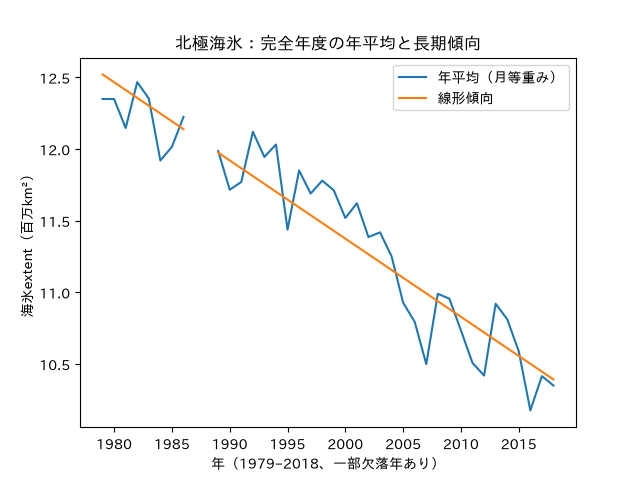

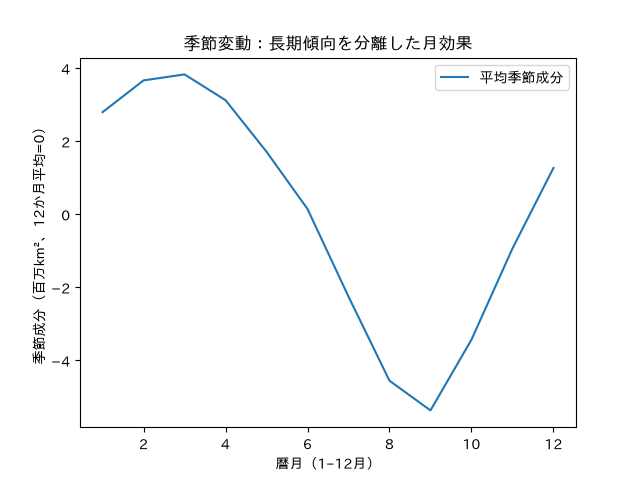

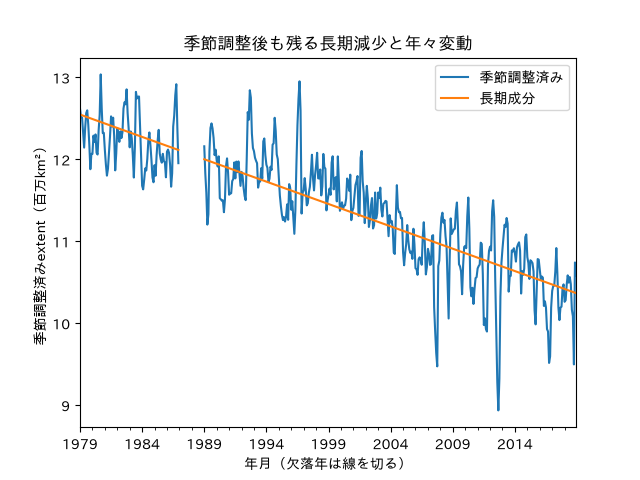

In [7]:
# 初回図表: 長期傾向・季節変動・分離後の時系列をそれぞれ表示
chart_metadata = []
def show_chart(frame, kind, x, y, title, xlabel, ylabel, filename):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png = visualization.render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
    glyphs = [str(w.message) for w in caught if 'Glyph' in str(w.message)]
    for warning in caught:
        if 'Glyph' not in str(warning.message):
            print('図警告:', str(warning.message))
    if glyphs:
        raise RuntimeError('図の文字欠落: ' + str(glyphs))
    output = visualization.build_image_output(png)
    display(output['data'], raw=True)
    (data_dir / filename).write_bytes(png)
    labels = [str(y)] if isinstance(y,str) else list(y)
    chart_metadata.append({'filename':filename,'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':labels,'missing_glyphs':[], 'png_sha256':hashlib.sha256(png).hexdigest()})
with phase('初回図表描画'):
    annual_plot=annual.set_index('year').reindex(range(1979,2019)).rename_axis('year').reset_index()
    show_chart(annual_plot, 'line', 'year', ['年平均（月等重み）','線形傾向'],
               '北極海氷：完全年度の年平均と長期傾向', '年（1979–2018、一部欠落年あり）', '海氷extent（百万km²）', '01-annual-trend.png')
    show_chart(seasonal_table,'line','月','平均季節成分',
               '季節変動：長期傾向を分離した月効果', '暦月（1–12月）', '季節成分（百万km²、12か月平均=0）', '02-seasonal-component.png')
    plot_monthly = monthly[['長期成分','季節調整済み']].reindex(pd.date_range('1979-01-01','2018-12-01',freq='MS'))
    plot_monthly.index.name='date'
    show_chart(plot_monthly.reset_index(),'line','date',['季節調整済み','長期成分'],
               '季節調整後も残る長期減少と年々変動', '年月（欠落年は線を切る）', '季節調整済みextent（百万km²）','03-adjusted-trend.png')
    print('図の文字欠落検査: なし。タイトル/軸/凡例:',json.dumps(chart_metadata,ensure_ascii=False,indent=2))

In [8]:
# 反復1: 観測間隔・重み・期間・頑健推定に対する感度
iteration_history = []
request_1 = '初回結果では隔日観測から日次観測への移行と42日ギャップがあり、月等重みの前提が未検証です。月の日数重み、観測率の閾値、全期間と1989年以降・両端5年除外、OLSとTheil–Senを比較し、長期減少の方向と効果量がどこまで安定するか確かめてください。'
iteration_history.append({'iteration':1,'request_original':request_1,'reason':'weighting前提がassumed。初期隔日と欠測・期間選択が推定に与える影響は未解決。'})
print('追加依頼文（原文）:', request_1)
def sensitivity_analysis(weight, estimator, period, coverage_rule):
    m = monthly_all.copy()
    cutoff = np.where(m.index < pd.Timestamp('1987-08-01'), .40 if coverage_rule=='relaxed' else .45, .60 if coverage_rule=='relaxed' else .90)
    ok = m.coverage.ge(cutoff) & m.extent.notna()
    complete = m.loc[ok].groupby('year').size().loc[lambda s:s.eq(12)].index
    m = m.loc[ok & m.year.isin(complete)]
    if weight=='day':
        series = m.assign(w=m.extent*m.days).groupby('year').w.sum()/m.groupby('year').days.sum()
    else:
        series = m.groupby('year').extent.mean()
    if period=='post1989': series=series.loc[series.index>=1989]
    if period=='trim5': series=series.loc[(series.index>=1984)&(series.index<=2013)]
    return (stats.theilslopes(series.to_numpy(),series.index.to_numpy()).slope if estimator=='theilsen' else stats.linregress(series.index,series).slope)*10
with phase('反復1・感度分析'):
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'weight':['month','day'],'estimator':['ols','theilsen'],
                'period':['full','post1989','trim5'],'coverage_rule':['strict','relaxed']}, max_runs=24)
    sensitivity_report = sensitivity.run_sensitivity(sensitivity_plan, sensitivity_analysis, stability_tolerance=.20)
    sensitivity_table = pd.DataFrame([{**r.specification,'百万km2毎10年':r.value} for r in sensitivity_report.results])
    sensitivity_summary = {'run_count':len(sensitivity_report.results),'stable':sensitivity_report.stable,
        'max_relative_deviation':sensitivity_report.max_relative_deviation,'tolerance':.20,
        'min_slope':float(sensitivity_table['百万km2毎10年'].min()),'max_slope':float(sensitivity_table['百万km2毎10年'].max()),
        'all_slopes_negative':bool(sensitivity_table['百万km2毎10年'].lt(0).all())}
    display(sensitivity_table); print(json.dumps(sensitivity_summary,ensure_ascii=False,indent=2))
    iteration_history[-1].update(result=sensitivity_summary,evidence='本セル感度表24仕様',limitations='Theil–Senも因果モデルではない。期間差は加速の証明ではない。閾値緩和では不完全月が入る。')
    sensitivity_table.to_csv(data_dir/'sensitivity.csv',index=False)

追加依頼文（原文）: 初回結果では隔日観測から日次観測への移行と42日ギャップがあり、月等重みの前提が未検証です。月の日数重み、観測率の閾値、全期間と1989年以降・両端5年除外、OLSとTheil–Senを比較し、長期減少の方向と効果量がどこまで安定するか確かめてください。
{
  "run_count": 24,
  "stable": true,
  "max_relative_deviation": 0.16939966662229225,
  "tolerance": 0.2,
  "min_slope": -0.6384350684931497,
  "max_slope": -0.5459511292124899,
  "all_slopes_negative": true
}


,weight,estimator,period,coverage_rule,百万km2毎10年
0,month,ols,full,strict,-0.545951
1,month,ols,full,relaxed,-0.549516
2,month,ols,post1989,strict,-0.624898
3,month,ols,post1989,relaxed,-0.624898
4,month,ols,trim5,strict,-0.568973
5,month,ols,trim5,relaxed,-0.575456
6,month,theilsen,full,strict,-0.564120
7,month,theilsen,full,relaxed,-0.564488
8,month,theilsen,post1989,strict,-0.638180
9,month,theilsen,post1989,relaxed,-0.638180


追加依頼文（原文）: 初回の固定季節分解では各月の減少率が同じと仮定されています。各月の長期傾向を同じ採用年で推定し、特に3月と9月を比較してください。初期と後期の季節曲線および年ごとの3月–9月差を用いて、季節振幅の変化が平均的減少に隠れていないか確認し、一定季節成分という前提を更新してください。
{
  "march_slope": -0.41603677767322017,
  "september_slope": -0.8096414645571798,
  "amplitude_slope": 0.393604686883962,
  "amplitude_HAC95CI": [
    0.2215645908290055,
    0.5656447829389184
  ],
  "early_peak_month": 3,
  "early_trough_month": 9,
  "late_peak_month": 3,
  "late_trough_month": 9,
  "all_months_negative": true
}


,月,百万km2毎10年,HAC下限,HAC上限,1981–2010基準平均,基準比%毎10年
0,1,-0.473699,-0.534398,-0.413000,14.401212,-3.289299
1,2,-0.461992,-0.524348,-0.399636,15.264213,-3.026634
2,3,-0.416037,-0.486571,-0.345503,15.394895,-2.702433
3,4,-0.367939,-0.450877,-0.285001,14.654375,-2.510781
4,5,-0.349887,-0.421503,-0.278271,13.259784,-2.638706
5,6,-0.471543,-0.514411,-0.428676,11.731921,-4.019320
6,7,-0.682095,-0.780236,-0.583954,9.426095,-7.236243
7,8,-0.749172,-0.860754,-0.637591,7.155081,-10.470489
8,9,-0.809641,-0.946572,-0.672710,6.347707,-12.754865
9,10,-0.781075,-0.930765,-0.631384,8.294973,-9.416240


,月,1979–1986（8年）,2011–2018（8年）
0,1,14.924061,13.481173
1,2,15.782956,14.340772
2,3,15.940441,14.611395
3,4,15.244208,14.019592
4,5,13.743157,12.577766
5,6,12.285342,10.821583
6,7,10.186026,8.014427
7,8,7.918443,5.546875
8,9,7.183317,4.654363
9,10,9.016569,6.614524


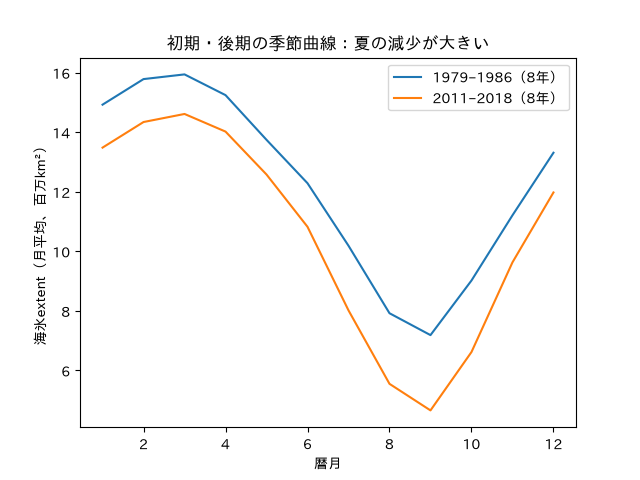

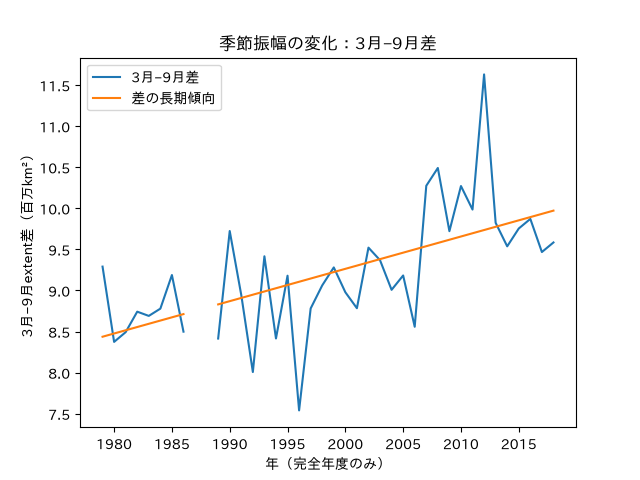

In [9]:
# 反復2: 一定の季節成分でよいか、月別傾向と季節振幅変化を検証
request_2 = '初回の固定季節分解では各月の減少率が同じと仮定されています。各月の長期傾向を同じ採用年で推定し、特に3月と9月を比較してください。初期と後期の季節曲線および年ごとの3月–9月差を用いて、季節振幅の変化が平均的減少に隠れていないか確認し、一定季節成分という前提を更新してください。'
iteration_history.append({'iteration':2,'request_original':request_2,'reason':'fixed-seasonがassumed。季節調整後の残差が大きく自己相関があるため、季節別の変化が結論を修正し得る。'})
print('追加依頼文（原文）:',request_2)
with phase('反復2・季節別変化'):
    records=[]
    for month, subset in monthly.groupby('month'):
        model = sm.OLS(subset.extent, sm.add_constant(subset.year.to_numpy(dtype=float))).fit(cov_type='HAC',cov_kwds={'maxlags':3},use_t=True)
        lo,hi=model.conf_int().iloc[1]*10
        base=subset.loc[subset.year.between(1981,2010),'extent'].mean()
        records.append({'月':month,'百万km2毎10年':float(model.params.iloc[1]*10),'HAC下限':lo,'HAC上限':hi,'1981–2010基準平均':base,'基準比%毎10年':float(model.params.iloc[1]*10/base*100)})
    month_trends=pd.DataFrame(records)
    pivot=monthly.pivot(index='year',columns='month',values='extent')
    amplitude=(pivot[3]-pivot[9]).rename('3月–9月差').reset_index()
    amplitude_model=sm.OLS(amplitude['3月–9月差'],sm.add_constant(amplitude.year.to_numpy(dtype=float))).fit(cov_type='HAC',cov_kwds={'maxlags':3},use_t=True)
    amplitude['差の長期傾向']=amplitude_model.predict(sm.add_constant(amplitude.year.to_numpy(dtype=float)))
    seasonal_comparison=pd.DataFrame({'月':range(1,13), '1979–1986（8年）':monthly.loc[monthly.year.between(1979,1986)].groupby('month').extent.mean().to_numpy(),
                         '2011–2018（8年）':monthly.loc[monthly.year.between(2011,2018)].groupby('month').extent.mean().to_numpy()})
    seasonal_summary={'march_slope':float(month_trends.loc[month_trends['月'].eq(3),'百万km2毎10年'].iloc[0]),
                      'september_slope':float(month_trends.loc[month_trends['月'].eq(9),'百万km2毎10年'].iloc[0]),
                      'amplitude_slope':float(amplitude_model.params.iloc[1]*10),
                      'amplitude_HAC95CI':(amplitude_model.conf_int().iloc[1]*10).tolist(),
                      'early_peak_month':int(seasonal_comparison.iloc[:,1].idxmax()+1),'early_trough_month':int(seasonal_comparison.iloc[:,1].idxmin()+1),
                      'late_peak_month':int(seasonal_comparison.iloc[:,2].idxmax()+1),'late_trough_month':int(seasonal_comparison.iloc[:,2].idxmin()+1),
                      'all_months_negative':bool(month_trends['百万km2毎10年'].lt(0).all())}
    display(month_trends); display(seasonal_comparison); print(json.dumps(seasonal_summary,ensure_ascii=False,indent=2))
    show_chart(seasonal_comparison,'line','月',['1979–1986（8年）','2011–2018（8年）'],
               '初期・後期の季節曲線：夏の減少が大きい', '暦月','海氷extent（月平均、百万km²）','04-seasonal-change.png')
    amplitude_plot=amplitude.set_index('year').reindex(range(1979,2019)).rename_axis('year').reset_index()
    show_chart(amplitude_plot,'line','year',['3月–9月差','差の長期傾向'],
               '季節振幅の変化：3月–9月差', '年（完全年度のみ）','3月–9月extent差（百万km²）','05-amplitude-change.png')
    iteration_history[-1].update(result=seasonal_summary,evidence='本セル月別傾向・振幅HAC回帰・初期後期図',limitations='固定季節成分は全期間の平均形だけを表す。12月別区間は同時推論ではない。3月–9月差は毎年の厳密な最大最小ではない。')
    month_trends.to_csv(data_dir/'month-trends.csv',index=False)

In [10]:
# 反復3: 自己相関・区間推定と季節差の頑健性
request_3 = '残差の自己相関が強く、通常の独立標本の有意性は信用できません。年平均傾向と3月–9月差の傾向についてHACのラグ1・3・5年と5暦年ブロックのwild bootstrapを比較してください。3月・9月の両方がある40年を使う場合とTheil–Senでも季節差の方向を確認し、区間推定が何を保証しないか記録してください。'
iteration_history.append({'iteration':3,'request_original':request_3,'reason':'自己相関と月ごとの傾向差が判明。HACラグ選択と完全年除外が季節差の区間に与える影響を未検証。'})
print('追加依頼文（原文）:',request_3)
def wild_block_interval(years, y, seed=22, repeats=2000):
    design=np.column_stack([np.ones(len(years)),np.asarray(years,dtype=float)-np.mean(years)])
    inverse=np.linalg.pinv(design)
    beta=inverse@np.asarray(y); residual=np.asarray(y)-design@beta
    block=((np.asarray(years)-min(years))//5).astype(int)
    blocks=np.unique(block); membership=np.searchsorted(blocks,block)
    rng=np.random.default_rng(seed)
    signs=rng.choice([-1.,1.],size=(repeats,len(blocks)))[:,membership]
    sample=design@beta+(signs*residual)
    slopes=(sample@inverse[1])*10
    return {'estimate':float(beta[1]*10),'ci95':np.quantile(slopes,[.025,.975]).tolist(),'n_blocks':len(blocks),'seed':seed,'repeats':repeats}
with phase('反復3・区間推定と季節差の検証'):
    uncertainty_records=[]
    for label, frame, column in [('annual',annual,'年平均（月等重み）'),('amplitude',amplitude,'3月–9月差')]:
        for lag in [1,3,5]:
            model=sm.OLS(frame[column],sm.add_constant(frame.year.to_numpy(dtype=float))).fit(cov_type='HAC',cov_kwds={'maxlags':lag},use_t=True)
            ci=model.conf_int().iloc[1]*10
            uncertainty_records.append({'target':label,'HAC_lag_years':lag,'slope':float(model.params.iloc[1]*10),'lower':float(ci.iloc[0]),'upper':float(ci.iloc[1])})
    uncertainty_table=pd.DataFrame(uncertainty_records)
    bootstrap_annual=wild_block_interval(annual.year.to_numpy(),annual['年平均（月等重み）'].to_numpy())
    bootstrap_amplitude=wild_block_interval(amplitude.year.to_numpy(),amplitude['3月–9月差'].to_numpy())
    alternate=monthly_all.loc[monthly_all.year.between(1979,2018) & monthly_all.valid].pivot(index='year',columns='month',values='extent')
    paired=(alternate[3]-alternate[9]).dropna()
    uncertainty_summary={'annual_wild_block':bootstrap_annual,'amplitude_wild_block':bootstrap_amplitude,
                         'amplitude_40year_ols_slope':float(stats.linregress(paired.index,paired).slope*10),
                         'amplitude_40year_n':len(paired),'amplitude_theilsen_slope':float(stats.theilslopes(amplitude['3月–9月差'],amplitude.year).slope*10),
                         'annual_all_HAC_CI_negative':bool(uncertainty_table.loc[uncertainty_table.target.eq('annual'),'upper'].lt(0).all()),
                         'amplitude_all_HAC_CI_positive':bool(uncertainty_table.loc[uncertainty_table.target.eq('amplitude'),'lower'].gt(0).all())}
    display(uncertainty_table); print(json.dumps(uncertainty_summary,ensure_ascii=False,indent=2))
    iteration_history[-1].update(result=uncertainty_summary,evidence='本セルHAC6仕様・seed22 bootstrap各2000回・40年対比較',
                                limitations='8ブロックのみ。ブロック間独立・局所的誤差構造は仮定。観測誤差、製品版変更、因果識別は検証しない。HACは欠落年を圧縮した観測年ラグの近似。')
    from dataclasses import replace
    revised_assumptions=[]
    for assumption in assumption_manifest.assumptions:
        if assumption.id=='weighting':
            assumption=replace(assumption,status='tested',statement='月等重みと日数重みで減少方向と20%以内の効果量を確認')
        if assumption.id=='fixed-season':
            assumption=replace(assumption,status='rejected',statement='季節形が一定という厳密な仮定は採用しない。固定月効果は平均的基準分解だけに使い、月別傾向と振幅変化を併記',conclusion_critical=False)
        revised_assumptions.append(assumption)
    revised_assumptions.append(analysis_assumptions.Assumption('seasonal-change','同じ年の3月–9月差の増加をHAC・wild block・Theil–Sen・40年で確認','tested',conclusion_critical=True))
    final_assumptions=replace(assumption_manifest,assumptions=tuple(revised_assumptions))
    final_findings=analysis_assumptions.check_manifest(final_assumptions)
    print('最終前提の検査結果:',[asdict(f) for f in final_findings])
    print('反復停止理由: 最大3回に達した。主要な減少方向・季節差は仕様と区間の比較で維持。因果・最新状態・製品独立検証は追加観測を要するため、本データへの追加当てはめで解決しない。')
    (data_dir/'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(final_assumptions),ensure_ascii=False,indent=2))
    (data_dir/'iteration-history.json').write_text(json.dumps(iteration_history,ensure_ascii=False,indent=2))
    uncertainty_table.to_csv(data_dir/'uncertainty-comparison.csv',index=False)

追加依頼文（原文）: 残差の自己相関が強く、通常の独立標本の有意性は信用できません。年平均傾向と3月–9月差の傾向についてHACのラグ1・3・5年と5暦年ブロックのwild bootstrapを比較してください。3月・9月の両方がある40年を使う場合とTheil–Senでも季節差の方向を確認し、区間推定が何を保証しないか記録してください。
{
  "annual_wild_block": {
    "estimate": -0.5459511292124913,
    "ci95": [
      -0.5984609950718756,
      -0.4960504927327639
    ],
    "n_blocks": 8,
    "seed": 22,
    "repeats": 2000
  },
  "amplitude_wild_block": {
    "estimate": 0.39360468688394545,
    "ci95": [
      0.22056517525022298,
      0.5706269467624543
    ],
    "n_blocks": 8,
    "seed": 22,
    "repeats": 2000
  },
  "amplitude_40year_ols_slope": 0.4022402330589685,
  "amplitude_40year_n": 40,
  "amplitude_theilsen_slope": 0.3539106699751871,
  "annual_all_HAC_CI_negative": true,
  "amplitude_all_HAC_CI_positive": true
}
最終前提の検査結果: []
反復停止理由: 最大3回に達した。主要な減少方向・季節差は仕様と区間の比較で維持。因果・最新状態・製品独立検証は追加観測を要するため、本データへの追加当てはめで解決しない。


,target,HAC_lag_years,slope,lower,upper
0,annual,1,-0.545951,-0.606852,-0.485050
1,annual,3,-0.545951,-0.601355,-0.490548
2,annual,5,-0.545951,-0.606075,-0.485827
3,amplitude,1,0.393605,0.231532,0.555678
4,amplitude,3,0.393605,0.221565,0.565645
5,amplitude,5,0.393605,0.211835,0.575374


In [11]:
# 根拠集約: 完全な実行出力をInsightの検証用MIMEに保存
from importlib.metadata import version
with phase('根拠集約と再現条件保存'):
    evidence_summary = {'annual_slope':main_summary['年平均傾向_百万km2毎10年'],
                        'seasonal_peak_month':main_summary['最大月'],'seasonal_trough_month':main_summary['最小月'],
                        'seasonal_peak_to_trough':main_summary['季節振幅_最大最小差_百万km2'],
                        'march_slope':seasonal_summary['march_slope'],'september_slope':seasonal_summary['september_slope'],
                        'amplitude_slope':seasonal_summary['amplitude_slope'],
                        'sensitivity_stable':sensitivity_summary['stable'],'sensitivity_max_relative_deviation':sensitivity_summary['max_relative_deviation'],
                        'sensitivity_slope_range':[sensitivity_summary['min_slope'],sensitivity_summary['max_slope']],
                        'annual_HAC95CI':uncertainty_table.loc[(uncertainty_table.target=='annual')&(uncertainty_table.HAC_lag_years==3),['lower','upper']].iloc[0].tolist(),
                        'amplitude_HAC95CI':seasonal_summary['amplitude_HAC95CI'],'rows_north':len(north),'complete_years':len(annual)}
    display({'text/plain':json.dumps(evidence_summary,ensure_ascii=False,indent=2)},raw=True)
    versions = {p:version(p) for p in ['kaggle','numpy','pandas','scipy','statsmodels','matplotlib','nbformat','japanize-matplotlib']}
    print('Python:',sys.version.split()[0]); print('パッケージ版:',json.dumps(versions))
    evidence_path=data_dir/'initial-evidence-reference.json'
    if evidence_path.exists():
        initial_evidence=json.loads(evidence_path.read_text())
        assert initial_evidence.keys()==evidence_summary.keys()
        for key,value in evidence_summary.items():
            if isinstance(value,(float,int,list)) and not isinstance(value,bool):
                assert np.allclose(value,initial_evidence[key],rtol=1e-10,atol=1e-12), f'再実行値が不一致: {key}'
            else:
                assert value==initial_evidence[key], f'再実行値が不一致: {key}'
        print('REPLAY_NUMERIC_MATCH=True (初回値とrtol=1e-10, atol=1e-12で一致)')
    else:
        evidence_path.write_text(json.dumps(evidence_summary,ensure_ascii=False,indent=2))
        print('初回数値参照を保存。カーネル再起動後の全セル再実行で比較する。')
    (data_dir/'environment.json').write_text(json.dumps({'python':sys.version,'versions':versions,'bootstrap_seed':22},indent=2))

Python: 3.12.3
パッケージ版: {"kaggle": "2.2.4", "numpy": "2.5.3", "pandas": "3.0.6", "scipy": "1.18.1", "statsmodels": "0.15.0", "matplotlib": "3.11.2", "nbformat": "5.11.1", "japanize-matplotlib": "1.1.3"}
REPLAY_NUMERIC_MATCH=True (初回値とrtol=1e-10, atol=1e-12で一致)


{
  "annual_slope": -0.5459511292125031,
  "seasonal_peak_month": 3,
  "seasonal_trough_month": 9,
  "seasonal_peak_to_trough": 9.200138355395627,
  "march_slope": -0.41603677767322017,
  "september_slope": -0.8096414645571798,
  "amplitude_slope": 0.393604686883962,
  "sensitivity_stable": true,
  "sensitivity_max_relative_deviation": 0.16939966662229225,
  "sensitivity_slope_range": [
    -0.6384350684931497,
    -0.5459511292124899
  ],
  "annual_HAC95CI": [
    -0.6013546418686889,
    -0.4905476165563174
  ],
  "amplitude_HAC95CI": [
    0.2215645908290055,
    0.5656447829389184
  ],
  "rows_north": 13177,
  "complete_years": 38
}

## 使用したJupytermindモジュール
直接import・呼び出したものだけを列挙する。間接利用は含めない。ローカル関数phase/show_chart/sensitivity_analysis/wild_block_intervalはNotebook側の補助関数。

| モジュール（ai_data_scientist配下） | 直接呼び出した関数・型 | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先の固定・原本配置・文書/メタデータの直列書込 |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込フェーズと完了/失敗状態 |
| ingestion | SourceSpec, ingest | ローカルCSV読込・行数制限 |
| cleaning | clean_dataset | 完全重複除去と影響記録 |
| eda | explore | 型・欠測・統計要約 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 来歴・単位・定義の信頼度記録 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 分析前提・因果範囲と未解決事項検査 |
| data_quality | detect_anomalies | 範囲・半球・非欠測・一意キーの意味的検査 |
| stats_analysis | correlation | 年と年平均の記述的相関。独立標本p値は主結論に使わない |
| sensitivity | SensitivityPlan, run_sensitivity | 24仕様の結論安定性 |
| visualization | render_chart, build_image_output | 日本語図5点と画像MIME保存 |
| insight_engine | extract_cited_value, record_insight | 実行済みMIME出力からの正確な引用と根拠manifest |
| notebook_audit | audit_notebook, audit_visual_outputs | 実行・根拠・visual_audit=True、および改善候補の最小再現 |

mcp_gateway.run_and_recordは未使用。このホストは既に外側のJupyter MCPツールを提供し、Notebook内へexecute(code)クライアントを注入するインターフェースはない。架空のMCPClientやローカルexecで代用せず、実行・出力保存はネイティブjupyter MCPのinsert_execute_code_cell/execute_cellを使用した。文書・根拠・チャートメタデータ変更はenqueue_write経由。

## Jupytermind改善候補
外部サービス問題と区別して以下2候補を記録する。ソースコードの修正・Issue登録は本依頼の対象外。

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| 機能不足：意味定義の未確認状態の一覧 | FieldValue(status="inferred")だけを持つmanifestでunresolved_fields() | unknownだけでなくinferredも一括把握できる専用APIまたはオプション | []を返す。実装docstring上はunknownのみであり、実装違反ではなくSkillの留保要求とのインターフェース差 | 推定された単位・定義が確認済みと誤解され得る | unknown一覧に加えinferredを明示走査・出力。本分析で実施 | 「時間軸・単位・意味的異常検査」セル、最終セルinferred_not_in_unresolved_fields=True |
| 監査不足：チャートメタデータ欠落 | 有効PNGを持つコードセルでmetadata.chartを完全に省略しaudit_visual_outputs | タイトル・軸・凡例・glyph情報が確認不能と警告 | ()を返し、メタデータが空だとラベル検査に入らない。record_chart/build_image_outputも自動でchart情報は付けない | visual_audit=Trueが未確認チャートを合格させ得る | 実描画時の警告捕捉と各図の仕様を保存し、最終書込でchartメタデータを明示補完。全5画像を目視確認 | 「初回図表」「反復2」セル・最終セルmissing_chart_metadata_not_flagged=True、chart-manifest.json |

切り分け：Kaggle認証・検索・CSV取得は成功。NSIDCの定義解説URL取得のHTTPErrorは外部HTTPアクセスの問題で、Jupytermind不具合ではない（生の資格情報・ヘッダは保存しない）。Jupyter MCPのcreateは親ディレクトリ不在で失敗したため一時Notebookでensure_notebookを呼び解消した。filesystem MCPの許可ディレクトリ制限は別ツール設定であり、内容除外ポリシーやJupytermindの問題ではない。ベンチマークランナーは呼び出しておらず評価不能。

## どこまで結論できるか・適用しなかった機能
このCSVの北半球extentでは、長期的減少・3月最大/9月最小の季節性・夏のより大きな減少を記述できる。原因別寄与、人為温暖化の効果量、将来の無氷年、最新2026年の状態は識別できない。元CSV末尾は2019-05-31であり、長期解析は1979–2018年の完全年38年（1987/1988除外）。観測年をまたぐ線形トレンドは期間要約であって毎年の単調変化や一定速度を保証しない。

Extentの百万km²単位はKaggleデータ辞書でverified。15%閾値の詳細と受動マイクロ波/NASA Teamの測定経路は値/パスからinferredで、公的解説のHTTP取得が失敗したためverifiedに昇格していない。Missingの詳細定義・ライセンスはunknown。北半球Missingは全行0だが、日付列に42日ギャップがあり「Missing=0だから欠測なし」ではない。定義の未確認事項は測定精度の解釈を制約するが、掲載Extentの単位付き時間的変化の記述とは区別する。

隔日観測をむやみに日次補間しない。月観測率閾値は45%/90%、移行月・ギャップ月は厳格に除外。感度では40%/60%も検査した。年平均は月等重みを主とし日数重みを比較。主分解は月固定効果+線形傾向の加法モデルで、STL/季節ARIMAは不連続系列の補間・欠測モデルを新たに仮定する必要があり本目的に追加価値が小さいため使わない。固定季節が厳密に一定という前提は棄却し、月別傾向と3月–9月差を最終結論に併記した。3月–9月差は日次の年間最大–最小ではない。

HACは自己相関を考慮した近似区間で、欠落年を詰めた観測年ラグと暦年ラグの差は残る。暦年5年区切りwild bootstrapは8ブロックだけであり、ブロック間独立性や厳密な被覆率は保証しない。観測誤差・センサー/製品版変更の独立検証は未実施。

validate_anomalies/compare_datasetsは独立参照データが提供/ロードされていないため未使用。別のKaggleコピーやseaborn版を独立観測とみなさない。Kaggleから取得できたため指定の公開CSVフォールバックは使わない。統計zスコアだけの異常検出は強い季節性を誤検知するため不採用、意味的制約と暦日キー/間隔を検査した。機械学習・因果推論・将来予測もこの記述目的には不適用。

## 反復依頼履歴
初回の根拠表・図を読み直し、結論に実質的影響を持つ点だけを最大3回追加した。追加依頼文は下記に原文のまま保存する。

### 反復 1

初回結果では隔日観測から日次観測への移行と42日ギャップがあり、月等重みの前提が未検証です。月の日数重み、観測率の閾値、全期間と1989年以降・両端5年除外、OLSとTheil–Senを比較し、長期減少の方向と効果量がどこまで安定するか確かめてください。

選定理由：weighting前提がassumed。初期隔日と欠測・期間選択が推定に与える影響は未解決。

結果・証拠：本セル感度表24仕様
```json
{
  "run_count": 24,
  "stable": true,
  "max_relative_deviation": 0.16939966662229225,
  "tolerance": 0.2,
  "min_slope": -0.6384350684931497,
  "max_slope": -0.5459511292124899,
  "all_slopes_negative": true
}
```
残る限界：Theil–Senも因果モデルではない。期間差は加速の証明ではない。閾値緩和では不完全月が入る。

### 反復 2

初回の固定季節分解では各月の減少率が同じと仮定されています。各月の長期傾向を同じ採用年で推定し、特に3月と9月を比較してください。初期と後期の季節曲線および年ごとの3月–9月差を用いて、季節振幅の変化が平均的減少に隠れていないか確認し、一定季節成分という前提を更新してください。

選定理由：fixed-seasonがassumed。季節調整後の残差が大きく自己相関があるため、季節別の変化が結論を修正し得る。

結果・証拠：本セル月別傾向・振幅HAC回帰・初期後期図
```json
{
  "march_slope": -0.41603677767322017,
  "september_slope": -0.8096414645571798,
  "amplitude_slope": 0.393604686883962,
  "amplitude_HAC95CI": [
    0.2215645908290055,
    0.5656447829389184
  ],
  "early_peak_month": 3,
  "early_trough_month": 9,
  "late_peak_month": 3,
  "late_trough_month": 9,
  "all_months_negative": true
}
```
残る限界：固定季節成分は全期間の平均形だけを表す。12月別区間は同時推論ではない。3月–9月差は毎年の厳密な最大最小ではない。

### 反復 3

残差の自己相関が強く、通常の独立標本の有意性は信用できません。年平均傾向と3月–9月差の傾向についてHACのラグ1・3・5年と5暦年ブロックのwild bootstrapを比較してください。3月・9月の両方がある40年を使う場合とTheil–Senでも季節差の方向を確認し、区間推定が何を保証しないか記録してください。

選定理由：自己相関と月ごとの傾向差が判明。HACラグ選択と完全年除外が季節差の区間に与える影響を未検証。

結果・証拠：本セルHAC6仕様・seed22 bootstrap各2000回・40年対比較
```json
{
  "annual_wild_block": {
    "estimate": -0.5459511292124913,
    "ci95": [
      -0.5984609950718756,
      -0.4960504927327639
    ],
    "n_blocks": 8,
    "seed": 22,
    "repeats": 2000
  },
  "amplitude_wild_block": {
    "estimate": 0.39360468688394545,
    "ci95": [
      0.22056517525022298,
      0.5706269467624543
    ],
    "n_blocks": 8,
    "seed": 22,
    "repeats": 2000
  },
  "amplitude_40year_ols_slope": 0.4022402330589685,
  "amplitude_40year_n": 40,
  "amplitude_theilsen_slope": 0.3539106699751871,
  "annual_all_HAC_CI_negative": true,
  "amplitude_all_HAC_CI_positive": true
}
```
残る限界：8ブロックのみ。ブロック間独立・局所的誤差構造は仮定。観測誤差、製品版変更、因果識別は検証しない。HACは欠落年を圧縮した観測年ラグの近似。

停止理由：3回の上限に達した。主要な方向と季節差は維持され、以降の重要な不確実性は追加データ/観測定義の検証を要する。単なる当てはめ追加では解決しない。

長期傾向：1979–2018年の完全年度38年では、月等重み年平均は10年あたり約0.546百万km²減少した。年HAC(3)95%区間は−0.601〜−0.491百万km²/10年。全年度が単調に減るという意味ではない。

```evidence
{"execution_count":11,"cited_value":"-0.5459511292125031","claim_type":"descriptive-trend"}
```

季節変動：平均的季節成分は3月最大、9月最小で、最大–最小差は約9.200百万km²。これは全期間の平均形であり、各年の季節形が一定という主張ではない。

```evidence
{"execution_count":11,"cited_value":"9.200138355395627","claim_type":"descriptive-seasonality"}
```

季節別の変化：9月は約−0.810、3月は約−0.416百万km²/10年。夏の最小期の減少の方が大きい。全12か月の点推定も負だった。12個の区間は同時信頼区間ではない。

```evidence
{"execution_count":11,"cited_value":"-0.8096414645571798","claim_type":"descriptive-seasonal-trend"}
```

季節振幅の変化：同じ年の3月–9月差は約+0.394百万km²/10年増加し、HAC(3)95%区間は+0.222〜+0.566。固定月効果による分解は平均的な基準表示に限定し、この変化を併記する。

```evidence
{"execution_count":11,"cited_value":"0.393604686883962","claim_type":"descriptive-amplitude-change"}
```

結論安定性：24仕様で年平均の傾きは−0.638〜−0.546百万km²/10年、すべて減少方向。stable=True、基準からの最大相対差は0.1694、事前に指定した20%許容内。ただし全ての可能な仕様への頑健性を保証しない。

```evidence
{"execution_count":11,"cited_value":"0.16939966662229225","claim_type":"sensitivity"}
```

In [ ]:
# 最終記録・図表監査・ライフサイクル（再実行時も根拠参照を更新）
with phase('改善候補の最小再現とNotebook文書化'):
    inference_probe = data_definition.build_manifest({}, {}, {'x':{'unit':data_definition.FieldValue('推定単位','inferred','試験')}})
    probe_inferred_not_reported = inference_probe.unresolved_fields() == []
    visual_probe = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('display(chart)',execution_count=1,
        outputs=[visualization.build_image_output((data_dir/'01-annual-trend.png').read_bytes())])])
    visual_probe.cells[0].outputs[0]['execution_count']=1
    probe_visual_metadata_not_reported = notebook_audit.audit_visual_outputs(visual_probe,(0,)) == ()
    print('改善候補の再現:', {'inferred_not_in_unresolved_fields':probe_inferred_not_reported,'missing_chart_metadata_not_flagged':probe_visual_metadata_not_reported})
    notebook_before=nbformat.read(handle.notebook_path,as_version=4)
    evidence_cell=next(c for c in notebook_before.cells if c.cell_type=='code' and c.source.startswith('# 根拠集約:'))
    evidence_execution_count=evidence_cell.execution_count
    evidence_text='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in evidence_cell.outputs)
    result={'output':evidence_text}
    claim_definitions=[
        ('annual_slope','長期傾向：1979–2018年の完全年度38年では、月等重み年平均は10年あたり約0.546百万km²減少した。年HAC(3)95%区間は−0.601〜−0.491百万km²/10年。全年度が単調に減るという意味ではない。','descriptive-trend'),
        ('seasonal_peak_to_trough','季節変動：平均的季節成分は3月最大、9月最小で、最大–最小差は約9.200百万km²。これは全期間の平均形であり、各年の季節形が一定という主張ではない。','descriptive-seasonality'),
        ('september_slope','季節別の変化：9月は約−0.810、3月は約−0.416百万km²/10年。夏の最小期の減少の方が大きい。全12か月の点推定も負だった。12個の区間は同時信頼区間ではない。','descriptive-seasonal-trend'),
        ('amplitude_slope','季節振幅の変化：同じ年の3月–9月差は約+0.394百万km²/10年増加し、HAC(3)95%区間は+0.222〜+0.566。固定月効果による分解は平均的な基準表示に限定し、この変化を併記する。','descriptive-amplitude-change'),
        ('sensitivity_max_relative_deviation','結論安定性：24仕様で年平均の傾きは−0.638〜−0.546百万km²/10年、すべて減少方向。stable=True、基準からの最大相対差は0.1694、事前に指定した20%許容内。ただし全ての可能な仕様への頑健性を保証しない。','sensitivity'),
    ]
    extracted_claims=[(insight_engine.extract_cited_value(result, '"'+key+r'":\s*([-0-9.e]+)'),text,kind) for key,text,kind in claim_definitions]
    modules_text='''## 使用したJupytermindモジュール
直接import・呼び出したものだけを列挙する。間接利用は含めない。ローカル関数phase/show_chart/sensitivity_analysis/wild_block_intervalはNotebook側の補助関数。

| モジュール（ai_data_scientist配下） | 直接呼び出した関数・型 | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先の固定・原本配置・文書/メタデータの直列書込 |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込フェーズと完了/失敗状態 |
| ingestion | SourceSpec, ingest | ローカルCSV読込・行数制限 |
| cleaning | clean_dataset | 完全重複除去と影響記録 |
| eda | explore | 型・欠測・統計要約 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 来歴・単位・定義の信頼度記録 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 分析前提・因果範囲と未解決事項検査 |
| data_quality | detect_anomalies | 範囲・半球・非欠測・一意キーの意味的検査 |
| stats_analysis | correlation | 年と年平均の記述的相関。独立標本p値は主結論に使わない |
| sensitivity | SensitivityPlan, run_sensitivity | 24仕様の結論安定性 |
| visualization | render_chart, build_image_output | 日本語図5点と画像MIME保存 |
| insight_engine | extract_cited_value, record_insight | 実行済みMIME出力からの正確な引用と根拠manifest |
| notebook_audit | audit_notebook, audit_visual_outputs | 実行・根拠・visual_audit=True、および改善候補の最小再現 |

mcp_gateway.run_and_recordは未使用。このホストは既に外側のJupyter MCPツールを提供し、Notebook内へexecute(code)クライアントを注入するインターフェースはない。架空のMCPClientやローカルexecで代用せず、実行・出力保存はネイティブjupyter MCPのinsert_execute_code_cell/execute_cellを使用した。文書・根拠・チャートメタデータ変更はenqueue_write経由。'''
    improvements_text='''## Jupytermind改善候補
外部サービス問題と区別して以下2候補を記録する。ソースコードの修正・Issue登録は本依頼の対象外。

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| 機能不足：意味定義の未確認状態の一覧 | FieldValue(status="inferred")だけを持つmanifestでunresolved_fields() | unknownだけでなくinferredも一括把握できる専用APIまたはオプション | []を返す。実装docstring上はunknownのみであり、実装違反ではなくSkillの留保要求とのインターフェース差 | 推定された単位・定義が確認済みと誤解され得る | unknown一覧に加えinferredを明示走査・出力。本分析で実施 | 「時間軸・単位・意味的異常検査」セル、最終セルinferred_not_in_unresolved_fields=True |
| 監査不足：チャートメタデータ欠落 | 有効PNGを持つコードセルでmetadata.chartを完全に省略しaudit_visual_outputs | タイトル・軸・凡例・glyph情報が確認不能と警告 | ()を返し、メタデータが空だとラベル検査に入らない。record_chart/build_image_outputも自動でchart情報は付けない | visual_audit=Trueが未確認チャートを合格させ得る | 実描画時の警告捕捉と各図の仕様を保存し、最終書込でchartメタデータを明示補完。全5画像を目視確認 | 「初回図表」「反復2」セル・最終セルmissing_chart_metadata_not_flagged=True、chart-manifest.json |

切り分け：Kaggle認証・検索・CSV取得は成功。NSIDCの定義解説URL取得のHTTPErrorは外部HTTPアクセスの問題で、Jupytermind不具合ではない（生の資格情報・ヘッダは保存しない）。Jupyter MCPのcreateは親ディレクトリ不在で失敗したため一時Notebookでensure_notebookを呼び解消した。filesystem MCPの許可ディレクトリ制限は別ツール設定であり、内容除外ポリシーやJupytermindの問題ではない。ベンチマークランナーは呼び出しておらず評価不能。'''
    limits_text='''## どこまで結論できるか・適用しなかった機能
このCSVの北半球extentでは、長期的減少・3月最大/9月最小の季節性・夏のより大きな減少を記述できる。原因別寄与、人為温暖化の効果量、将来の無氷年、最新2026年の状態は識別できない。元CSV末尾は2019-05-31であり、長期解析は1979–2018年の完全年38年（1987/1988除外）。観測年をまたぐ線形トレンドは期間要約であって毎年の単調変化や一定速度を保証しない。

Extentの百万km²単位はKaggleデータ辞書でverified。15%閾値の詳細と受動マイクロ波/NASA Teamの測定経路は値/パスからinferredで、公的解説のHTTP取得が失敗したためverifiedに昇格していない。Missingの詳細定義・ライセンスはunknown。北半球Missingは全行0だが、日付列に42日ギャップがあり「Missing=0だから欠測なし」ではない。定義の未確認事項は測定精度の解釈を制約するが、掲載Extentの単位付き時間的変化の記述とは区別する。

隔日観測をむやみに日次補間しない。月観測率閾値は45%/90%、移行月・ギャップ月は厳格に除外。感度では40%/60%も検査した。年平均は月等重みを主とし日数重みを比較。主分解は月固定効果+線形傾向の加法モデルで、STL/季節ARIMAは不連続系列の補間・欠測モデルを新たに仮定する必要があり本目的に追加価値が小さいため使わない。固定季節が厳密に一定という前提は棄却し、月別傾向と3月–9月差を最終結論に併記した。3月–9月差は日次の年間最大–最小ではない。

HACは自己相関を考慮した近似区間で、欠落年を詰めた観測年ラグと暦年ラグの差は残る。暦年5年区切りwild bootstrapは8ブロックだけであり、ブロック間独立性や厳密な被覆率は保証しない。観測誤差・センサー/製品版変更の独立検証は未実施。

validate_anomalies/compare_datasetsは独立参照データが提供/ロードされていないため未使用。別のKaggleコピーやseaborn版を独立観測とみなさない。Kaggleから取得できたため指定の公開CSVフォールバックは使わない。統計zスコアだけの異常検出は強い季節性を誤検知するため不採用、意味的制約と暦日キー/間隔を検査した。機械学習・因果推論・将来予測もこの記述目的には不適用。'''
    history_text='## 反復依頼履歴\n初回の根拠表・図を読み直し、結論に実質的影響を持つ点だけを最大3回追加した。追加依頼文は下記に原文のまま保存する。\n'
    for item in iteration_history:
        history_text += '\n### 反復 '+str(item['iteration'])+'\n\n'+item['request_original']+'\n\n選定理由：'+item['reason']+'\n\n結果・証拠：'+item['evidence']+'\n```json\n'+json.dumps(item['result'],ensure_ascii=False,indent=2)+'\n```\n残る限界：'+item['limitations']+'\n'
    history_text += '\n停止理由：3回の上限に達した。主要な方向と季節差は維持され、以降の重要な不確実性は追加データ/観測定義の検証を要する。単なる当てはめ追加では解決しない。'
    sections=[('modules',modules_text),('improvements',improvements_text),('limits',limits_text),('iterations',history_text)]
    with phase('Notebook文書・チャート情報書込',writing=True):
        def refresh(nb):
            nb.cells=[c for c in nb.cells if not c.metadata.get('exp22_generated')]
            for cell in nb.cells:
                if cell.cell_type=='code' and cell.source.startswith('# 初回図表:'):
                    specs=chart_metadata[:3]
                    cell.metadata['chart']={**specs[0],'title':' / '.join(s['title'] for s in specs),'legend':[s['legend'] for s in specs],'specifications':specs}
                if cell.cell_type=='code' and cell.source.startswith('# 反復2:'):
                    specs=chart_metadata[3:]
                    cell.metadata['chart']={**specs[0],'title':' / '.join(s['title'] for s in specs),'legend':[s['legend'] for s in specs],'specifications':specs}
            for label,text in sections:
                nb.cells.append(nbformat.v4.new_markdown_cell(text,metadata={'exp22_generated':label}))
            nb.metadata['v020_exp22']={'run_id':RUN_ID,'provenance':provenance,'chart_count':len(chart_metadata),'versions':versions}
        project_manager.enqueue_write(handle,refresh)
        for cited,text,kind in extracted_claims:
            insight_engine.record_insight(handle,text,evidence_execution_count,cited,kind,language='ja')
        def order_final(nb):
            for cell in nb.cells:
                if cell.cell_type=='markdown' and '```evidence' in cell.source:
                    cell.metadata['exp22_generated']='insight'
            final_cells=[c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 最終記録・図表監査')]
            nb.cells=[c for c in nb.cells if c not in final_cells]+final_cells
        project_manager.enqueue_write(handle,order_final)
        (data_dir/'chart-manifest.json').write_text(json.dumps(chart_metadata,ensure_ascii=False,indent=2))
with phase('notebook_audit visual_audit=True'):
    audit_report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('NOTEBOOK_AUDIT:',json.dumps({**asdict(audit_report),'ok':audit_report.ok},ensure_ascii=False,indent=2))
    if not audit_report.ok:
        raise RuntimeError('Notebook監査失敗。findingsを修正する必要があります。')
with phase('監査と実行ログ保存',writing=True):
    (data_dir/'notebook-audit.json').write_text(json.dumps({**asdict(audit_report),'ok':audit_report.ok},ensure_ascii=False,indent=2))
lifecycle.mark_completed(RUN_ID)
status=lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert status.state=='completed' and status.active_cell_executions==0 and status.pending_notebook_writes==0 and status.locks_held==0
(data_dir/'lifecycle.json').write_text(json.dumps({'status':asdict(status),'phase_log':phase_log},ensure_ascii=False,indent=2))
print('LIFECYCLE_FINAL:',json.dumps(asdict(status),ensure_ascii=False))
